In [1]:
import ast
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 160
BATCH_SIZE = 16
EPOCHS = 1.5
LR = 2e-5

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: False


## Load FABSA from Hugging Face

In [2]:
dataset = load_dataset("jordiclive/FABSA")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/747k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/158k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7930 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1057 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1587 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 7930
    })
    validation: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1057
    })
    test: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1587
    })
})

In [3]:
def to_df(split):
    return dataset[split].to_pandas()

train_df = to_df("train")
val_df = to_df("validation")
test_df = to_df("test")

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()


(7930, 7) (1057, 7) (1587, 7)


,id,org_index,data_source,industry,text,labels,label_codes
0,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,"[[Staff support: Attitude of staff, negative],...","['staff-support.attitude-of-staff.-1', 'compan..."
1,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it ...","[[Company brand: General satisfaction, positiv...","['company-brand.general-satisfaction.1', 'comp..."
2,301980653,369,Google Play,Ride Hailing,Sometimes it takes,"[[Company brand: General satisfaction, negative]]",['company-brand.general-satisfaction.-1']
3,301979991,727,Apple Store,Fashion,This is the worst app I ordered my sneakers 2/...,"[[Logistics rides: Speed, negative], [Online e...","['logistics-rides.speed.-1', 'online-experienc..."
4,301984330,549,Google Play,Travel Booking,So easy & loads of info !,"[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']


## Parse labels robustly and extract aspect/sentiment space

In [4]:
def _ensure_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if x is None:
        return []
    if isinstance(x, float) and pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
            if isinstance(parsed, np.ndarray):
                return parsed.tolist()
        except Exception:
            return []
    return []

def parse_from_label_codes(codes):
    codes = _ensure_list(codes)
    pairs = []
    sentiment_map = {"1": "positive", "-1": "negative", "0": "neutral"}
    for code in codes:
        if not isinstance(code, str):
            continue
        code = code.replace("\ufeff", "").replace("\ufffe", "")
        parts = code.rsplit(".", 1)
        if len(parts) != 2:
            continue
        aspect_code, sent_code = parts
        sentiment = sentiment_map.get(sent_code.strip())
        if sentiment is None:
            continue
        aspect = aspect_code.replace(".", ": ", 1).replace("-", " ").strip()
        pairs.append([aspect, sentiment])
    return pairs

def clean_label_pairs(labels):
    labels = _ensure_list(labels)
    out = []
    for item in labels:
        if isinstance(item, (list, tuple, np.ndarray)) and len(item) == 2:
            aspect, sent = item
            aspect = str(aspect).replace("\ufeff", "").replace("\ufffe", "").strip()
            sent = str(sent).lower().strip()
            out.append([aspect, sent])
    return out

def normalize_labels_cell(labels, label_codes):
    parsed = clean_label_pairs(labels)
    if parsed:
        return parsed
    return parse_from_label_codes(label_codes)

for df in [train_df, val_df, test_df]:
    df["labels_parsed"] = [
        normalize_labels_cell(lbl, codes)
        for lbl, codes in zip(df["labels"], df["label_codes"])
    ]

all_aspects = sorted({
    aspect
    for df in [train_df, val_df, test_df]
    for labels in df["labels_parsed"]
    for aspect, sent in labels
})

all_sentiments = sorted({
    sent.lower()
    for df in [train_df, val_df, test_df]
    for labels in df["labels_parsed"]
    for aspect, sent in labels
})

print("Number of aspects:", len(all_aspects))
print("Sentiments:", all_sentiments)
print("First 5 aspects:", all_aspects[:5])
train_df[["labels", "label_codes", "labels_parsed"]].head(3)


Number of aspects: 12
Sentiments: ['negative', 'neutral', 'positive']
First 5 aspects: ['Account management: Account access', 'Company brand: Competitor', 'Company brand: General satisfaction', 'Company brand: Reviews', 'Logistics rides: Speed']


,labels,label_codes,labels_parsed
0,"[[Staff support: Attitude of staff, negative],...","['staff-support.attitude-of-staff.-1', 'compan...","[[Staff support: Attitude of staff, negative],..."
1,"[[Company brand: General satisfaction, positiv...","['company-brand.general-satisfaction.1', 'comp...","[[Company brand: General satisfaction, positiv..."
2,"[[Company brand: General satisfaction, negative]]",['company-brand.general-satisfaction.-1'],"[[Company brand: General satisfaction, negative]]"


## 3. Quick EDA

Aspect count entries: 12
Pair count entries: 36


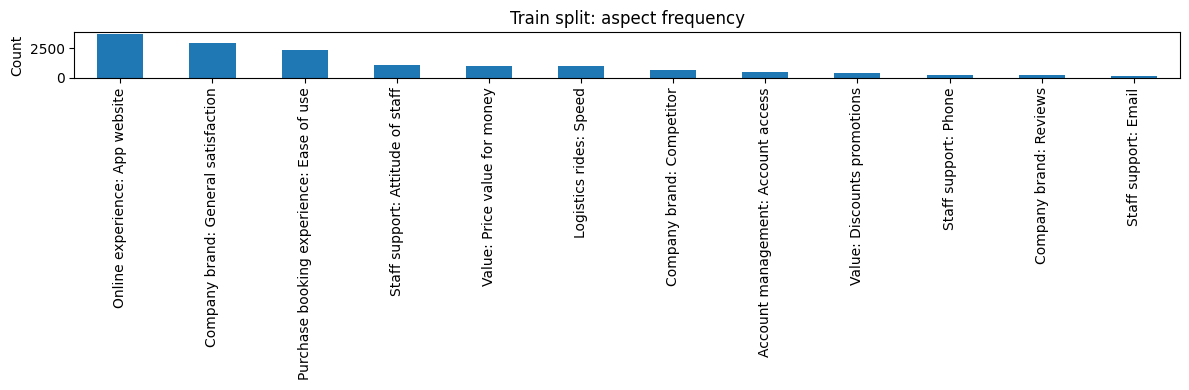

/tmp/ipykernel_3732/1408082705.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


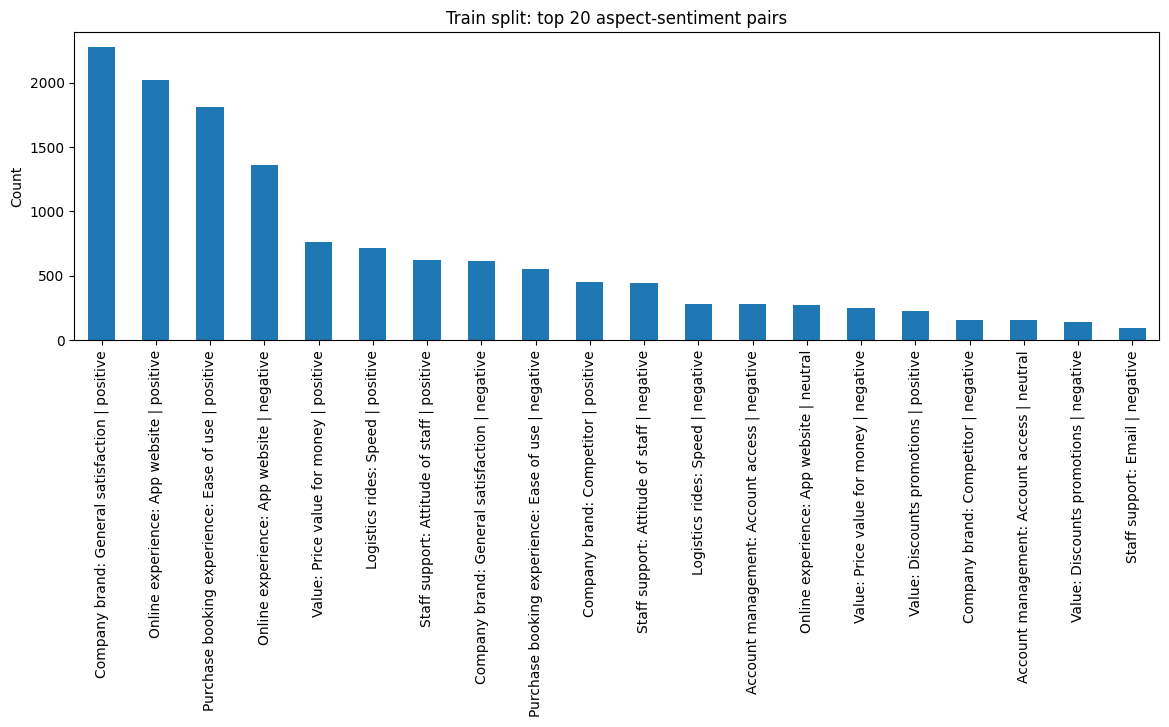

In [5]:
aspect_counter = Counter()
pair_counter = Counter()

for labels in train_df["labels_parsed"]:
    for aspect, sent in labels:
        sent = str(sent).lower()
        aspect_counter[aspect] += 1
        pair_counter[(aspect, sent)] += 1

aspect_series = pd.Series(dict(aspect_counter), dtype="int64").sort_values(ascending=False)
pair_series = pd.Series(
    {f"{a} | {s}": c for (a, s), c in pair_counter.items()},
    dtype="int64"
).sort_values(ascending=False)

print("Aspect count entries:", len(aspect_series))
print("Pair count entries:", len(pair_series))

if len(aspect_series) > 0:
    plt.figure(figsize=(12, 4))
    aspect_series.plot(kind="bar")
    plt.title("Train split: aspect frequency")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

if len(pair_series) > 0:
    plt.figure(figsize=(14, 4))
    pair_series.head(20).plot(kind="bar")
    plt.title("Train split: top 20 aspect-sentiment pairs")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


# Model Architecture

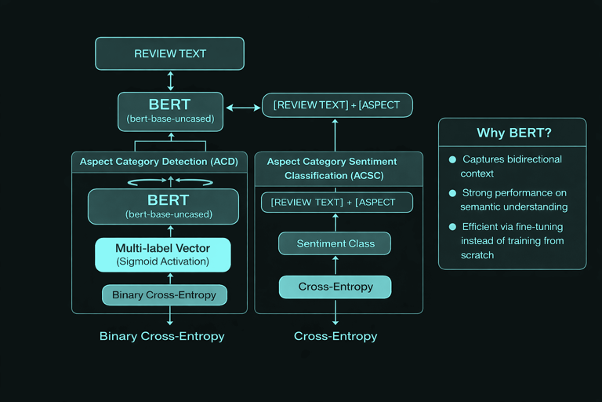

The architecture uses a pre-trained BERT model to encode input review text and capture rich contextual representations. It first performs Aspect Category Detection (ACD) as a multi-label classification task, using a sigmoid-activated output layer trained with binary cross-entropy to identify relevant aspects in the text. The detected aspects are then combined with the original review text and passed into a second BERT-based module for Aspect Category Sentiment Classification (ACSC). This module predicts the sentiment for each aspect using a standard classification head optimized with cross-entropy loss. Overall, the design leverages BERT’s bidirectional context and efficient fine-tuning to jointly model aspect detection and sentiment classification in a structured pipeline

## ACD with BERT (multi-label classification)

In [6]:
def get_acd_targets(df):
    return [[aspect for aspect, sent in labels] for labels in df["labels_parsed"]]

mlb = MultiLabelBinarizer(classes=all_aspects)
Y_train_acd = mlb.fit_transform(get_acd_targets(train_df)).astype(np.float32)
Y_val_acd = mlb.transform(get_acd_targets(val_df)).astype(np.float32)
Y_test_acd = mlb.transform(get_acd_targets(test_df)).astype(np.float32)

print("ACD label shape:", Y_train_acd.shape)


ACD label shape: (7930, 12)


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_acd_hf = Dataset.from_dict({
    "text": train_df["text"].astype(str).tolist(),
    "labels": Y_train_acd.tolist()
})
val_acd_hf = Dataset.from_dict({
    "text": val_df["text"].astype(str).tolist(),
    "labels": Y_val_acd.tolist()
})
test_acd_hf = Dataset.from_dict({
    "text": test_df["text"].astype(str).tolist(),
    "labels": Y_test_acd.tolist()
})

def tokenize_acd(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_acd_tok = train_acd_hf.map(tokenize_acd, batched=True)
val_acd_tok = val_acd_hf.map(tokenize_acd, batched=True)
test_acd_tok = test_acd_hf.map(tokenize_acd, batched=True)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7930 [00:00<?, ? examples/s]

Map:   0%|          | 0/1057 [00:00<?, ? examples/s]

Map:   0%|          | 0/1587 [00:00<?, ? examples/s]

In [8]:
acd_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(all_aspects),
    problem_type="multi_label_classification"
)

def compute_acd_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "subset_accuracy": accuracy_score(labels, preds),
    }

acd_args = TrainingArguments(
    output_dir="./bert_acd",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_micro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

acd_trainer = Trainer(
    model=acd_model,
    args=acd_args,
    train_dataset=train_acd_tok,
    eval_dataset=val_acd_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_acd_metrics,
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


When loading the pretrained BERT checkpoint into a sequence classification architecture, some pretrained weights were unused and the classification head was newly initialized, which is expected during downstream fine-tuning.

In [9]:
acd_trainer.train()

val_out = acd_trainer.predict(val_acd_tok)
test_out = acd_trainer.predict(test_acd_tok)

val_probs = 1 / (1 + np.exp(-val_out.predictions))
test_probs = 1 / (1 + np.exp(-test_out.predictions))

def threshold_search(y_true, probs, grid=np.arange(0.2, 0.81, 0.05)):
    best_t, best_f1 = 0.5, -1
    for t in grid:
        preds = (probs >= t).astype(int)
        score = f1_score(y_true, preds, average="micro", zero_division=0)
        if score > best_f1:
            best_t, best_f1 = t, score
    return best_t, best_f1

best_t, best_val_f1 = threshold_search(Y_val_acd, val_probs)
test_pred_acd = (test_probs >= best_t).astype(int)

print("Best validation threshold:", best_t)
print("Validation micro-F1:", best_val_f1)
print("Test micro-F1:", f1_score(Y_test_acd, test_pred_acd, average="micro", zero_division=0))
print("Test macro-F1:", f1_score(Y_test_acd, test_pred_acd, average="macro", zero_division=0))
print("Test subset accuracy:", accuracy_score(Y_test_acd, test_pred_acd))

acd_report = classification_report(
    Y_test_acd,
    test_pred_acd,
    target_names=mlb.classes_,
    zero_division=0,
    output_dict=True
)
acd_report_df = pd.DataFrame(acd_report).T
acd_report_df.sort_values("f1-score", ascending=False).head(15)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Subset Accuracy
1,0.222245,0.215336,0.690956,0.346003,0.414380


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Best validation threshold: 0.3
Validation micro-F1: 0.7227564102564102
Test micro-F1: 0.7341682836479096
Test macro-F1: 0.46399532355878875
Test subset accuracy: 0.4303717706364209


,precision,recall,f1-score,support
Online experience: App website,0.846154,0.926796,0.884641,724.0
Value: Price value for money,0.743363,0.815534,0.777778,206.0
Purchase booking experience: Ease of use,0.689922,0.884692,0.775261,503.0
Staff support: Attitude of staff,0.771574,0.756219,0.763819,201.0
samples avg,0.764014,0.778649,0.744345,2791.0
micro avg,0.723072,0.745611,0.734168,2791.0
Logistics rides: Speed,0.844444,0.603175,0.703704,189.0
Company brand: General satisfaction,0.603234,0.836207,0.700867,580.0
weighted avg,0.684725,0.745611,0.698608,2791.0
macro avg,0.518830,0.459730,0.463995,2791.0


## ACSC with BERT (multi-class classification)

In [10]:
def build_pair_df(df):
    rows = []
    for _, row in df.iterrows():
        for aspect, sent in row["labels_parsed"]:
            rows.append({
                "text": row["text"],
                "aspect": aspect,
                "sentiment": str(sent).lower(),
                "pair_text": f"{row['text']} [ASPECT] {aspect}"
            })
    return pd.DataFrame(rows)

train_pair_df = build_pair_df(train_df)
val_pair_df = build_pair_df(val_df)
test_pair_df = build_pair_df(test_df)

label_encoder = LabelEncoder()
y_train_sent = label_encoder.fit_transform(train_pair_df["sentiment"])
y_val_sent = label_encoder.transform(val_pair_df["sentiment"])
y_test_sent = label_encoder.transform(test_pair_df["sentiment"])

train_acsc_hf = Dataset.from_dict({
    "text": train_pair_df["pair_text"].tolist(),
    "labels": y_train_sent.tolist()
})
val_acsc_hf = Dataset.from_dict({
    "text": val_pair_df["pair_text"].tolist(),
    "labels": y_val_sent.tolist()
})
test_acsc_hf = Dataset.from_dict({
    "text": test_pair_df["pair_text"].tolist(),
    "labels": y_test_sent.tolist()
})

def tokenize_acsc(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_acsc_tok = train_acsc_hf.map(tokenize_acsc, batched=True)
val_acsc_tok = val_acsc_hf.map(tokenize_acsc, batched=True)
test_acsc_tok = test_acsc_hf.map(tokenize_acsc, batched=True)


Map:   0%|          | 0/13998 [00:00<?, ? examples/s]

Map:   0%|          | 0/1858 [00:00<?, ? examples/s]

Map:   0%|          | 0/2812 [00:00<?, ? examples/s]

In [11]:
acsc_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

def compute_acsc_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "micro_f1": f1_score(labels, preds, average="micro"),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

acsc_args = TrainingArguments(
    output_dir="./bert_acsc",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

acsc_trainer = Trainer(
    model=acsc_model,
    args=acsc_args,
    train_dataset=train_acsc_tok,
    eval_dataset=val_acsc_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_acsc_metrics,
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
60,0.588282


Test accuracy: 0.813655761024182
Test micro-F1: 0.813655761024182
Test macro-F1: 0.5271859027771789
              precision    recall  f1-score   support

    negative     0.8104    0.6250    0.7057       896
     neutral     0.0000    0.0000    0.0000        91
    positive     0.8147    0.9468    0.8758      1825

    accuracy                         0.8137      2812
   macro avg     0.5417    0.5239    0.5272      2812
weighted avg     0.7870    0.8137    0.7933      2812



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


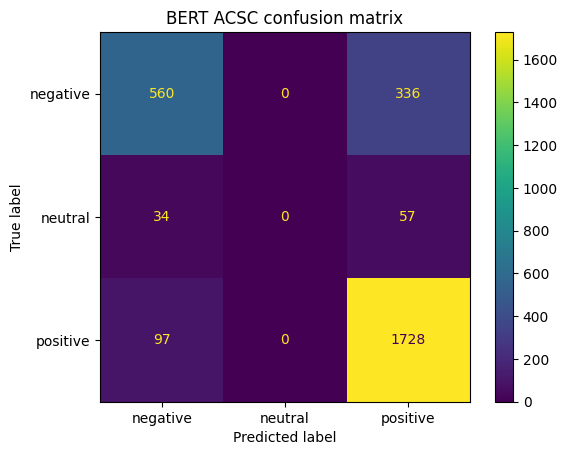

In [17]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Make the existing trainer run much faster
acsc_trainer.args.max_steps = 60
acsc_trainer.args.num_train_epochs = 1
acsc_trainer.args.logging_steps = 10

# Reduce overhead if these attributes exist in your version
if hasattr(acsc_trainer.args, "save_strategy"):
    acsc_trainer.args.save_strategy = "no"
if hasattr(acsc_trainer.args, "evaluation_strategy"):
    acsc_trainer.args.evaluation_strategy = "no"
if hasattr(acsc_trainer.args, "eval_strategy"):
    acsc_trainer.args.eval_strategy = "no"

# Increase batch size if memory allows
if hasattr(acsc_trainer.args, "per_device_train_batch_size"):
    acsc_trainer.args.per_device_train_batch_size = 16
if hasattr(acsc_trainer.args, "per_device_eval_batch_size"):
    acsc_trainer.args.per_device_eval_batch_size = 32

# Train for a short capped run
acsc_trainer.train()

# Evaluate
test_acsc_out = acsc_trainer.predict(test_acsc_tok)
test_logits = test_acsc_out.predictions
test_pred_sent = np.argmax(test_logits, axis=1)

print("Test accuracy:", accuracy_score(y_test_sent, test_pred_sent))
print("Test micro-F1:", f1_score(y_test_sent, test_pred_sent, average="micro"))
print("Test macro-F1:", f1_score(y_test_sent, test_pred_sent, average="macro"))

print(classification_report(
    y_test_sent,
    test_pred_sent,
    target_names=label_encoder.classes_,
    digits=4
))

cm = confusion_matrix(y_test_sent, test_pred_sent)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("BERT ACSC confusion matrix")
plt.show()

## End-to-end ABSA evaluation

In [18]:
from datasets import Dataset
import numpy as np

def predict_aspects_for_texts(texts, threshold=best_t):
    temp_hf = Dataset.from_dict({
        "text": list(texts),
        "labels": [[0.0] * len(all_aspects) for _ in range(len(texts))]
    })
    temp_tok = temp_hf.map(tokenize_acd, batched=True)
    logits = acd_trainer.predict(temp_tok).predictions
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= threshold).astype(int)

    aspect_lists = []
    for i, row in enumerate(preds):
        labels = [mlb.classes_[j] for j, v in enumerate(row) if v == 1]
        if not labels:
            labels = [mlb.classes_[int(np.argmax(probs[i]))]]
        aspect_lists.append(labels)
    return aspect_lists

def predict_sentiments_for_pairs(text_aspect_pairs, batch_size=64):
    pair_texts = [f"{text} [ASPECT] {aspect}" for text, aspect in text_aspect_pairs]

    ds = Dataset.from_dict({
        "text": pair_texts,
        "labels": [0] * len(pair_texts)
    })
    tok = ds.map(tokenize_acsc, batched=True)

    if hasattr(acsc_trainer.args, "per_device_eval_batch_size"):
        acsc_trainer.args.per_device_eval_batch_size = batch_size

    logits = acsc_trainer.predict(tok).predictions
    pred_idx = np.argmax(logits, axis=1)
    pred_labels = label_encoder.inverse_transform(pred_idx)

    return pred_labels.tolist()

gold_pairs = []
pred_pairs = []

predicted_aspects = predict_aspects_for_texts(test_df["text"].tolist())

all_text_aspect_pairs = []
pair_counts = []

for row, pred_aspects in zip(test_df.itertuples(index=False), predicted_aspects):
    pair_counts.append(len(pred_aspects))
    for aspect in pred_aspects:
        all_text_aspect_pairs.append((row.text, aspect))

predicted_sentiments = predict_sentiments_for_pairs(all_text_aspect_pairs, batch_size=64)

idx = 0
for row, pred_aspects in zip(test_df.itertuples(index=False), predicted_aspects):
    gold = {(a, s.lower()) for a, s in row.labels_parsed}

    current_preds = set()
    for aspect in pred_aspects:
        sentiment = predicted_sentiments[idx].lower()
        current_preds.add((aspect, sentiment))
        idx += 1

    gold_pairs.append(gold)
    pred_pairs.append(current_preds)

def multilabel_pair_f1(gold_sets, pred_sets):
    tp = fp = fn = 0
    for gold, pred in zip(gold_sets, pred_sets):
        tp += len(gold & pred)
        fp += len(pred - gold)
        fn += len(gold - pred)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return {"precision": precision, "recall": recall, "f1": f1}

end_to_end = multilabel_pair_f1(gold_pairs, pred_pairs)
print(end_to_end)

Map:   0%|          | 0/1587 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Map:   0%|          | 0/2884 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'precision': 0.6095700416086652, 'recall': 0.6251778093881134, 'f1': 0.6172752803987396}


##Results of BERT fine tuning

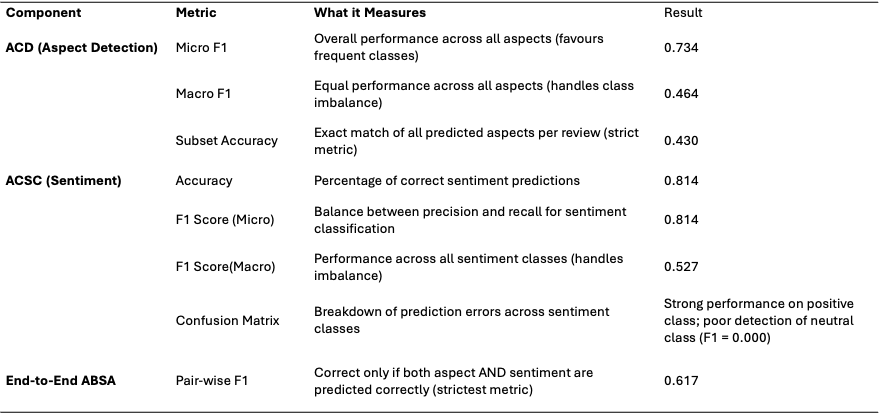